## Análise Univariada

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

df = pd.read_csv('../dados/taylor_swift_limpo.csv')
features_continuas = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'duration_ms'
]

### Resumo estatístico

In [26]:
display(df[features_continuas].describe().T[['mean', 'std', 'min', '50%', 'max']])

,mean,std,min,50%,max
danceability,0.585454,0.115011,0.292000,0.5980,0.897
energy,0.559528,0.176609,0.151000,0.5630,0.916
loudness,-7.877354,2.655783,-15.512000,-7.6100,-1.927
speechiness,0.058466,0.057149,0.025000,0.0403,0.519
acousticness,0.350880,0.326550,0.000191,0.2200,0.971
instrumentalness,0.003247,0.027204,0.000000,0.0000,0.333
liveness,0.136576,0.077519,0.039100,0.1120,0.596
valence,0.393987,0.187951,0.038400,0.3800,0.920
duration_ms,236827.157205,47420.272884,131907.000000,232253.0000,613026.000


### Histogramas e Distribuição

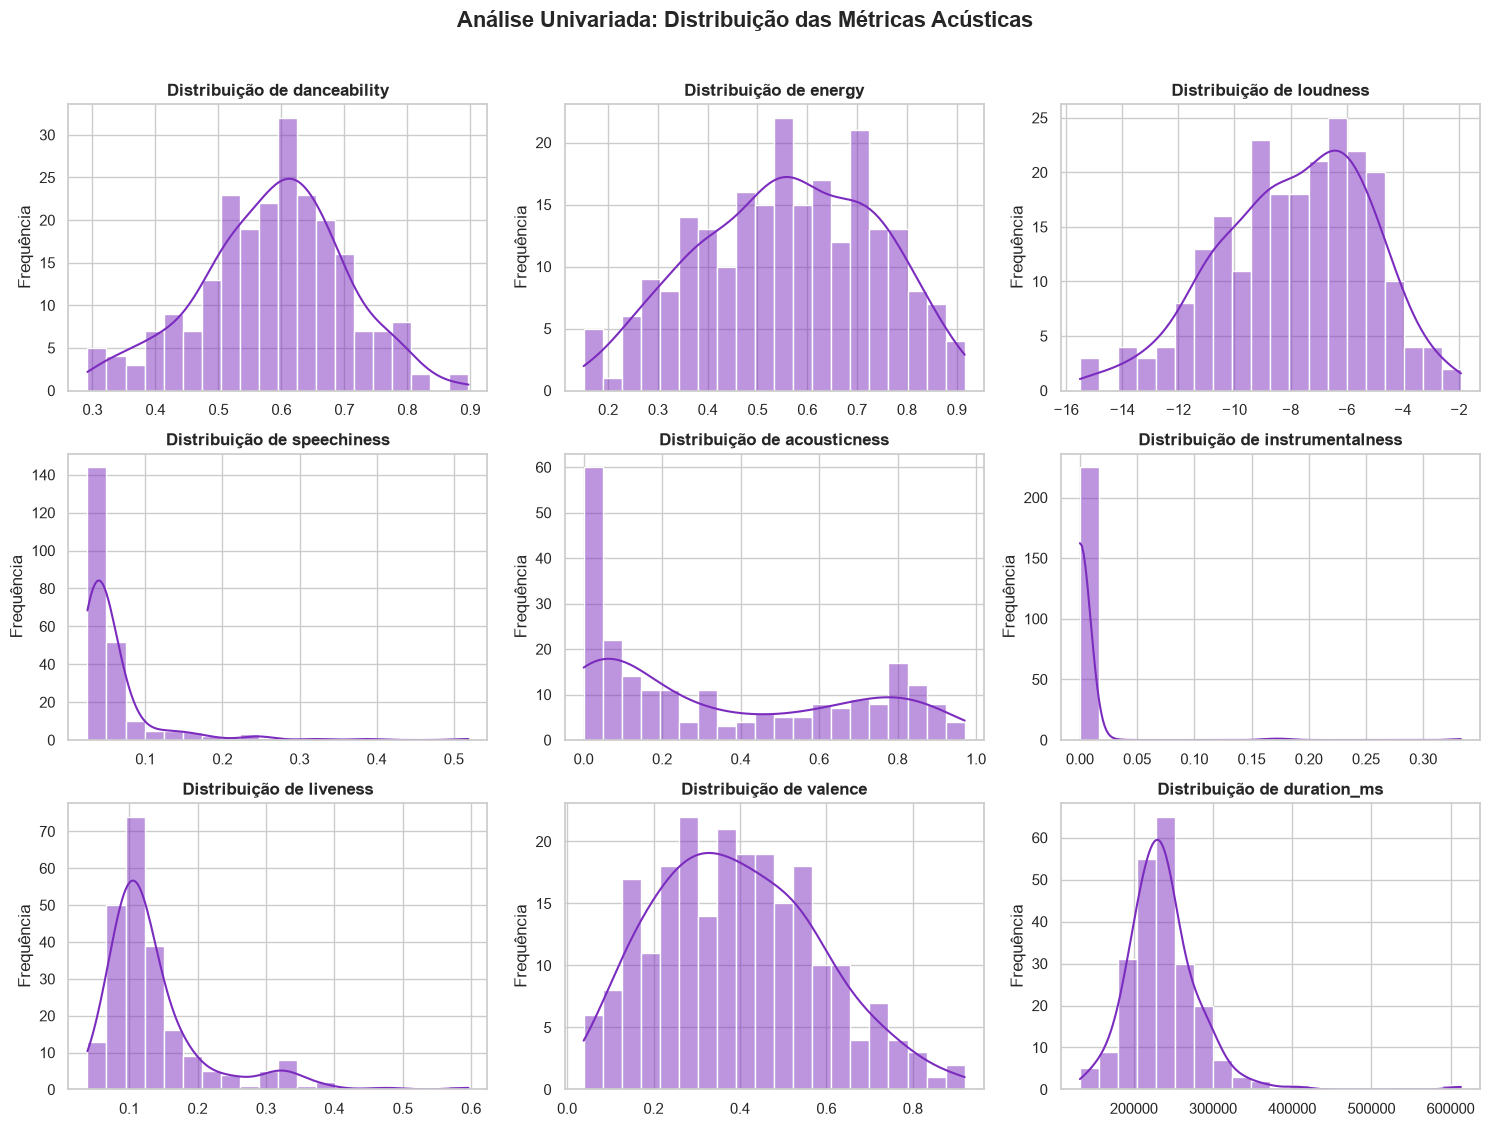

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(features_continuas):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#7b2cbf', bins=20)
    axes[i].set_title(f'Distribuição de {col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequência')

plt.suptitle('Análise Univariada: Distribuição das Métricas Acústicas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Boxplots

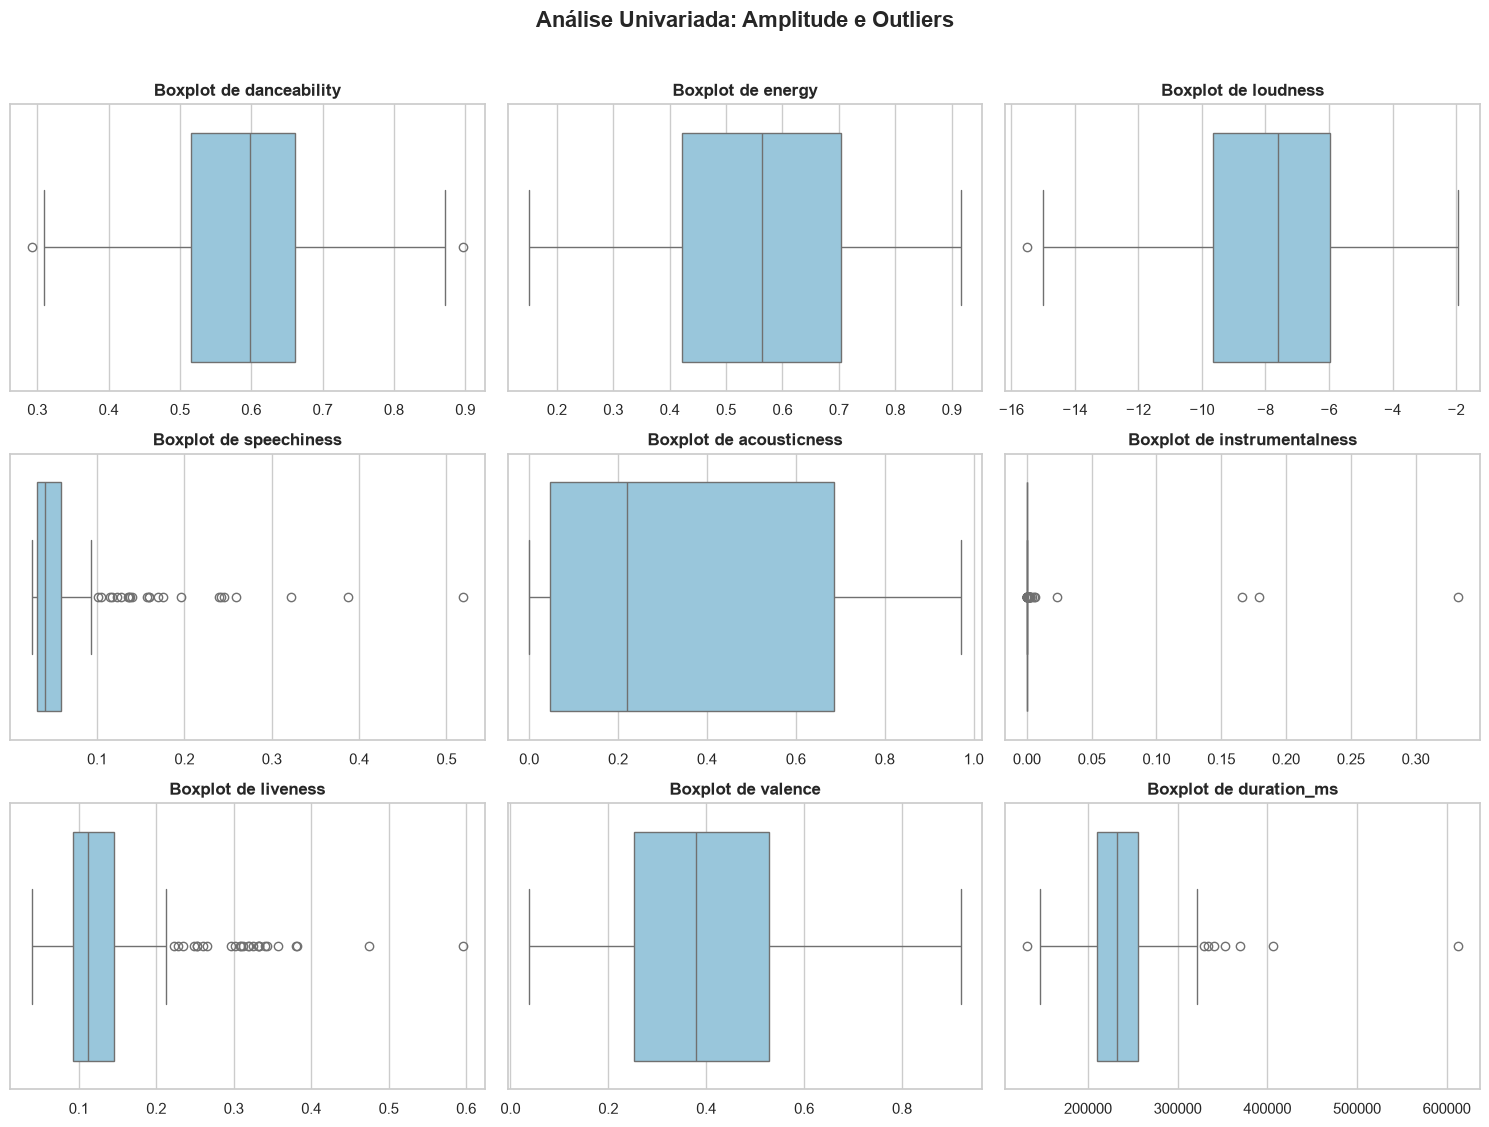

In [28]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(features_continuas):
    sns.boxplot(x=df[col], ax=axes[i], color='#8ecae6')
    axes[i].set_title(f'Boxplot de {col}', fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Análise Univariada: Amplitude e Outliers', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Total de músicas e faixas explícitas

C:\Users\caiog\AppData\Local\Temp\ipykernel_15428\2020528733.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Clean', 'Explicit'])


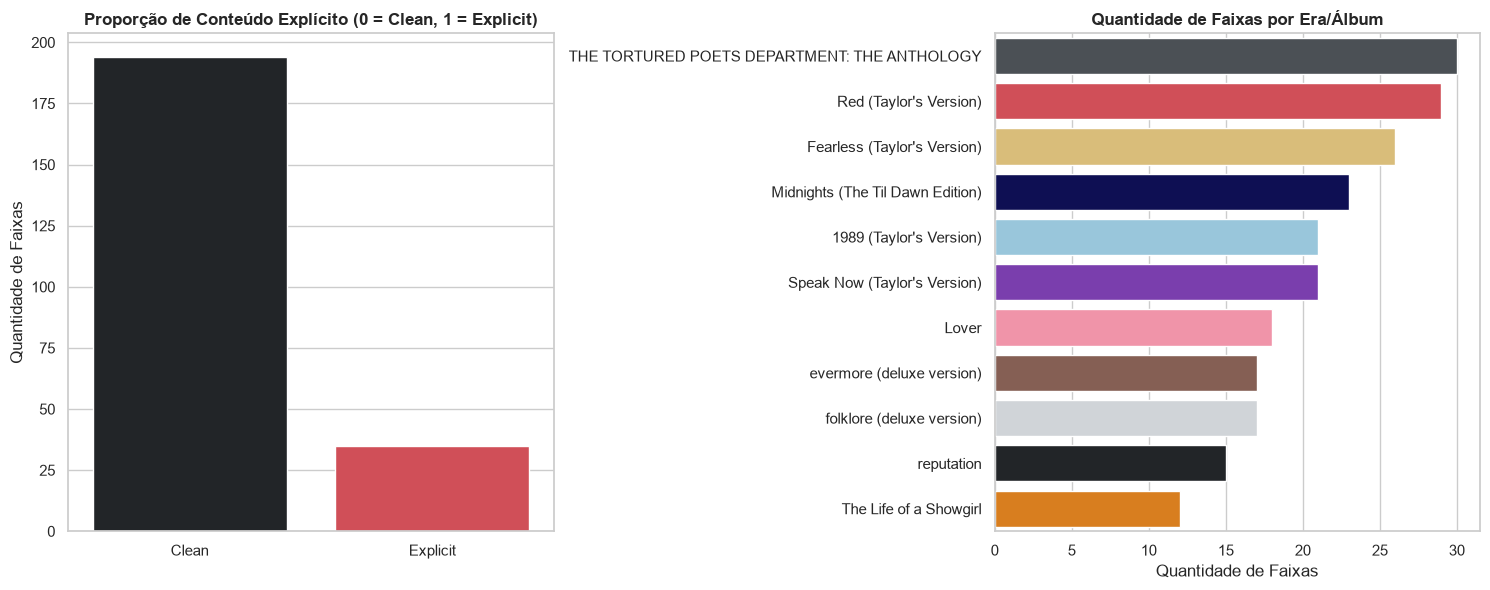

In [29]:
ordem_albuns = [
    'Taylor Swift', 
    "Fearless (Taylor's Version)", 
    "Speak Now (Taylor's Version)",
    "Red (Taylor's Version)",
    "1989 (Taylor's Version)",
    "reputation",
    "Lover",
    "folklore (deluxe version)",
    "evermore (deluxe version)",
    "Midnights (The Til Dawn Edition)",
    "THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY",
    "The Life of a Showgirl"
]

cores_eras = [
    '#2b9348', 
    '#e9c46a', 
    '#7b2cbf',  
    '#e63946',  
    '#8ecae6',  
    '#212529', 
    '#ff85a1',  
    '#ced4da', 
    '#8d5b4c',  
    '#03045e',  
    '#495057',  
    '#f77f00'   
]

palette_dict = dict(zip(ordem_albuns, cores_eras))
ordem_quantidade = df['album_name'].value_counts().index
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(
    data=df, 
    x='explicit', 
    ax=axes[0], 
    palette=['#212529', '#e63946'],
    hue='explicit',
    legend=False
)
axes[0].set_title('Proporção de Conteúdo Explícito (0 = Clean, 1 = Explicit)', fontweight='bold')
axes[0].set_xticklabels(['Clean', 'Explicit'])
axes[0].set_ylabel('Quantidade de Faixas')
axes[0].set_xlabel('')

sns.countplot(
    data=df, 
    y='album_name', 
    ax=axes[1], 
    order=ordem_quantidade, 
    palette=palette_dict,
    hue='album_name',
    legend=False
)
axes[1].set_title('Quantidade de Faixas por Era/Álbum', fontweight='bold')
axes[1].set_xlabel('Quantidade de Faixas')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

##  Conclusão da Análise Univariada
A análise univariada das métricas acústicas e metadados das 12 eras da Taylor Swift permitiu mapear o perfil individual das variáveis, fornecendo diagnósticos essenciais para a interpretação de negócio e decisões de modelagem:

###  Principais Achados
1. **Comportamento das Métricas Contínuas:**
   * **Gaussianas/Simétricas:** Variaveis como `danceability`, `energy`, `loudness` e `valence` apresentam distribuições bem balanceadas ao longo do catálogo, refletindo a versatilidade pop da artista, com médias moderadas a altas de energia e dançabilidade.
   * **Bimodalidade em `acousticness`:** A distribuição apresenta picos distintos em valores próximos de $0.0$ e $0.8$. Isso marca claramente o contraste entre a produção eufórica/synth-pop de eras como *1989* e *reputation* e os arranjos predominantemente acústicos das eras *folklore* e *evermore*.

2. **Assimetria e Outliers Reais:**
   * Métricas como `speechiness`, `instrumentalness` e `liveness` possuem forte assimetria positiva (concentradas perto de 0). 
   * A ausência quase total de `instrumentalness` é condizente com um repertório focado em vocal/composição. Os *outliers* observados em `duration_ms` (como a versão de 10 minutos de *"All Too Well"*) e `speechiness` representam trechos falados ou faixas estendidas legítimas do catálogo, e não ruídos de captura.

3. **Conteúdo Explícito e Volume por Era:**
   * A proporção de faixas com selo `explicit` é minoritária e concentrada fortemente do álbum *folklore* em diante.
   * Existe um desbalanceamento no volume de faixas por classe (álbum), impulsionado por lançamentos do tipo *Anthology* e edições *Taylor's Version* (com faixas *From The Vault*).

## Análise Bivariada

### Matriz de Correlação

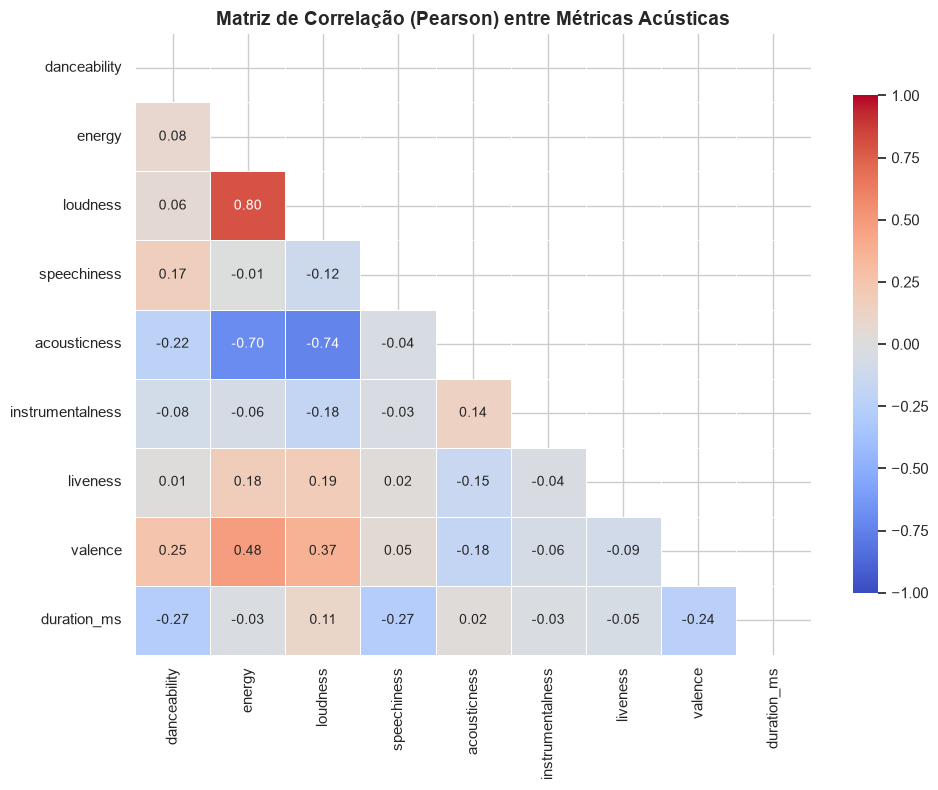

In [30]:
plt.figure(figsize=(10, 8))
matriz_corr = df[features_continuas].corr()
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(
    matriz_corr, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    cbar_kws={"shrink": .8},
    linewidths=0.5
)

plt.title('Matriz de Correlação (Pearson) entre Métricas Acústicas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Boxplots

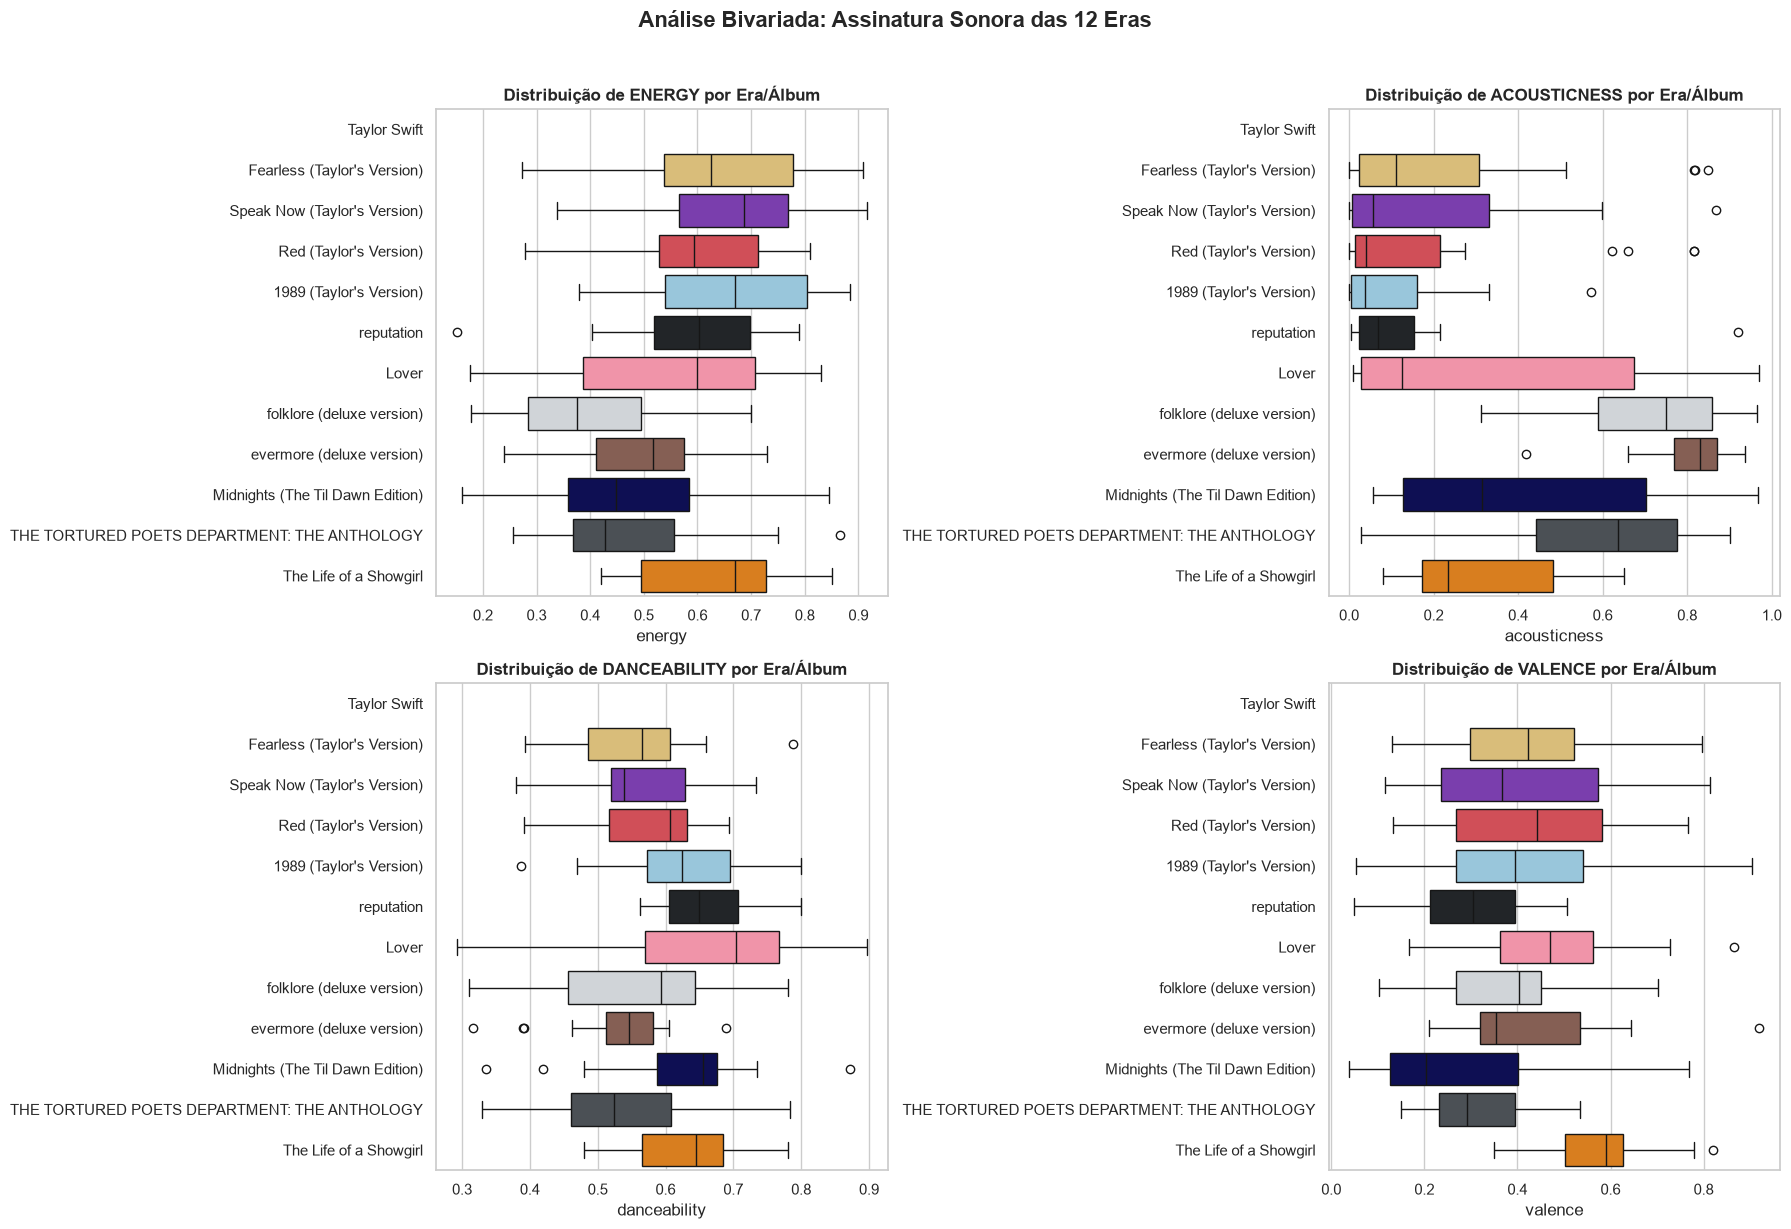

In [31]:
palette_dict = dict(zip(ordem_albuns, cores_eras))
features_chave = ['energy', 'acousticness', 'danceability', 'valence']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features_chave):
    sns.boxplot(
        data=df_filtered,
        y='album_name',       
        x=col,              
        order=ordem_albuns,
        palette=palette_dict,
        ax=axes[i],
        hue='album_name',
        legend=False
    )
    axes[i].set_title(f'Distribuição de {col.upper()} por Era/Álbum', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('')
    axes[i].set_xlabel(col)

plt.suptitle('Análise Bivariada: Assinatura Sonora das 12 Eras', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##  Conclusão da Análise Bivariada
A análise bivariada permitiu examinar tanto as interdependências entre as características de áudio quanto a evolução da assinatura sonora da Taylor Swift ao longo de suas 12 eras.

### 1. Principais Correlações entre Métricas Acústicas (Heatmap)

* **`energy` vs. `loudness` ($r = 0.80$):** Forte correlação positiva direta. Músicas mais barulhentas/com produção mais pesada tendem a entregar uma percepção de energia significativamente maior.
* **`acousticness` vs. `energy` ($r = -0.70$) e `loudness` ($r = -0.74$):** Forte correlação negativa. Faixas predominantemente acústicas sofrem uma queda proporcional drástica em intensidade sonora e dinamismo sintético.
* **`energy` vs. `valence` ($r = 0.48$):** Correlação moderada positiva, indicando que faixas mais eufóricas e animadas tendem a apresentar uma tonalidade emocional mais positiva/alegre.
* **Independência de `danceability`:** Surpreendentemente, a dançabilidade possui baixíssima correlação com a energia ($r = 0.08$), mostrando que uma faixa não precisa ser "barulhenta" ou agitada para ter um ritmo propício para dançar.

### 2. Assinatura Sonora e Transição entre Eras (Boxplots)

* **O Tríduo Orgânico (*folklore*, *evermore* e *TTPD*):**
  * **`acousticness`:** Apresenta picos expressivos em *folklore* e *evermore* (medianas acima de $0.7$), além de alta presença em *TTPD: The Anthology*, marcando a guinada para o indie-folk/folk-pop acústico.
  * **`energy`:** No caminho inverso, essas três eras registram os menores níveis de energia do catálogo inteiro.
* **O Bloco Pop / Eufórico (*1989*, *reputation*, *Lover* e *Showgirl*):**
  * **`danceability`:** *reputation*, *Lover* e *1989* exibem as maiores medianas de dançabilidade do histórico (~$0.65$ a $0.70$).
  * **`energy`:** *1989*, *Fearless* e *The Life of a Showgirl* figuram no topo em entrega de energia sonora.
* **A Dualidade Emocional de `valence`:**
  * Eras como *Midnights*, *reputation* e *TTPD* possuem as medianas de *valence* mais baixas (predomínio de temas melancólicos, introspectivos ou sombrios).
  * Em contrapartida, *Fearless*, *Red* e *Lover* concentram as faixas mais "solares" e otimistas.


## Análise Multivariada

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 
    'duration_ms', 'explicit'
]

X = df_filtered[features]
y = df_filtered['album_name']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Agrupamentos e Densidade com t-SNE

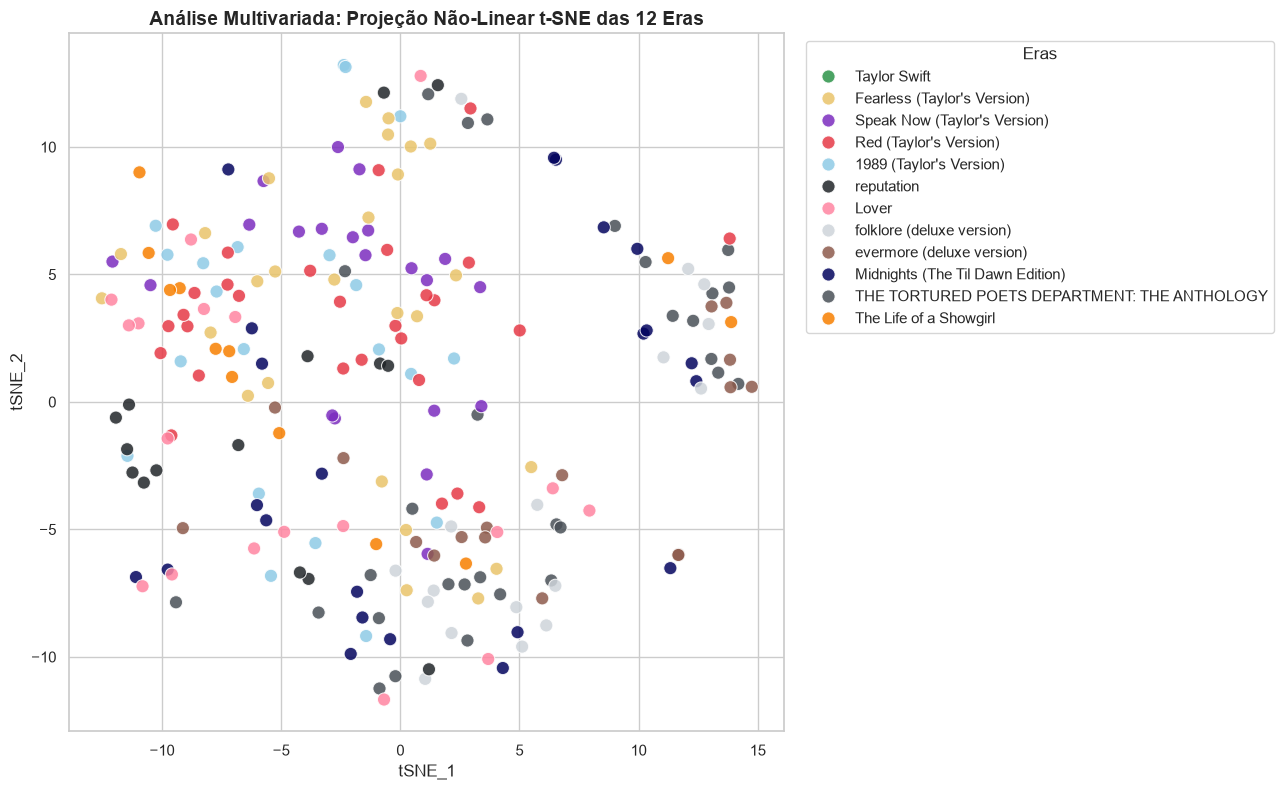

In [33]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame(X_tsne, columns=['tSNE_1', 'tSNE_2'])
df_tsne['album'] = y.values

plt.figure(figsize=(13, 8))
sns.scatterplot(
    data=df_tsne, 
    x='tSNE_1', 
    y='tSNE_2', 
    hue='album', 
    hue_order=ordem_albuns,
    palette=palette_dict,
    s=90, 
    alpha=0.85
)
plt.title('Análise Multivariada: Projeção Não-Linear t-SNE das 12 Eras', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Eras")
plt.tight_layout()
plt.show()

### Biplot (PCA)

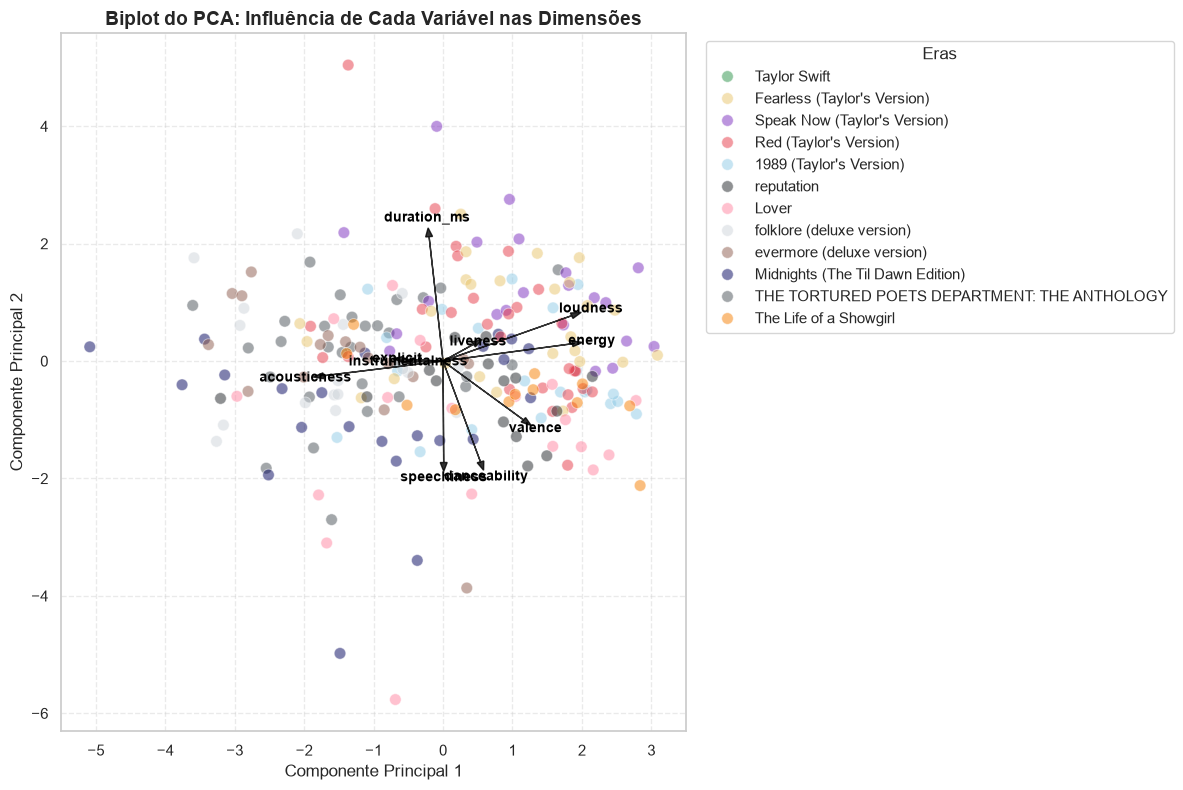

In [34]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], 
    hue=y, hue_order=ordem_albuns, palette=palette_dict, 
    alpha=0.5, s=70
)

loadings = pca.components_.T
scale_factor = 3.5 

for i, feature in enumerate(features):
    plt.arrow(
        0, 0, 
        loadings[i, 0] * scale_factor, 
        loadings[i, 1] * scale_factor, 
        color='black', alpha=0.8, head_width=0.1
    )
    plt.text(
        loadings[i, 0] * scale_factor * 1.15, 
        loadings[i, 1] * scale_factor * 1.15, 
        feature, color='black', ha='center', va='center', fontweight='bold'
    )

plt.title('Biplot do PCA: Influência de Cada Variável nas Dimensões', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Eras")
plt.tight_layout()
plt.show()

## Conclusão da Análise Multivariada

A análise multivariada permitiu ir além das relações de pares e mapear a estrutura global do catálogo em subespaços reduzidos (PCA e t-SNE), revelando os eixos conceituais que regem a sonoridade da artista.


### 1. Interpretação do Biplot (PCA)

O Biplot permitiu atribuir um significado físico/sonoro claro aos dois primeiros Componentes Principais com base nas vetores das variáveis (*loadings*):

* **Eixo Horizontal (Componente Principal 1 - 'Acoustic vs. Production'):**
  * **Oposição Direta:** O vetor de `acousticness` aponta fortemente para a esquerda (valores negativos), enquanto `energy` e `loudness` apontam para a direita (valores positivos).
  * **Significado:** O PC1 mede a **intensidade da produção sonora**. Músicas à direita do gráfico são produções pop/rock energéticas e sintetizadas, enquanto músicas à esquerda representam arranjos folk/acústicos desnudados (*folklore*, *evermore*, partes do *TTPD*).

* **Eixo Vertical (Componente Principal 2 - 'Structure & Rhythm'):**
  * **Vetor Superior (`duration_ms`):** Aponta verticalmente para cima, separando faixas longas e estruturalmente complexas (como faixas do *Speak Now* e *Red*).
  * **Vetores Inferiores (`danceability`, `speechiness`, `valence`):** Apontam para baixo, indicando faixas com ritmos bem definidos, vocais ritmados/falados e maior apelo dançante (*Lover*, *1989*, *Showgirl*).


### 2. Agrupamentos e Densidade com t-SNE

A projeção não-linear do t-SNE revelou padrões de vizinhança local que o PCA (linear) não consegue isolar completamente:

* **Isolamento da 'Era Orgânica/Folclórica':**
  * À direita do mapa do t-SNE (região em torno de $\text{tSNE\_1} > 10$), forma-se um *cluster* extremamente coeso composto quase exclusivamente por faixas de *folklore*, *evermore* e *TTPD: The Anthology* (tons de cinza e marrom).
  * Isso confirma que este bloco possui uma identidade sonora **única e bem demarcada** em relação ao resto da discografia.

* **A 'Grande Massa Pop':**
  * As eras *1989*, *Lover*, *Fearless* e *The Life of a Showgirl* compartilham regiões centrais e superiores do espaço com forte sobreposição.
  * Isso indica uma **alta variabilidade interna** nesses álbuns (misturando faixas acústicas lentas e *up-tempo synth-pop*), o que torna a classificação puramente linear por álbum um desafio para modelos preditivos.